In [1]:
import numpy as np
import scipy as sp
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.font_manager import FontProperties
from tqdm import tqdm

from bell_coupling_circuit_revisited_2 import BellCircuit

plt.style.use('science')

h = 6.62607015e-34
hbar = 1.054571817e-34
e = 1.60217663e-19

BellCircuit class has been imported!


# (1) Optimal parameters

We would like to design a circuit where the qubit gap is around 4-5GHz and longitudinal coupling is around 200-500MHz.

The longitudinal coupling increases with decreasing $C_{jp}, C_p, C_g$, or with increasing $C_{cp}$. Based on this, we also aim to simultaneously enhance the qubit gap.

In [2]:
system = BellCircuit(Ejp=6e9, Cjp=3e-15, Lp=400e-9, Cp=3e-15, Cg=3e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=5e-15, Cct=5e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)

qubit frequency vs Josephson energy

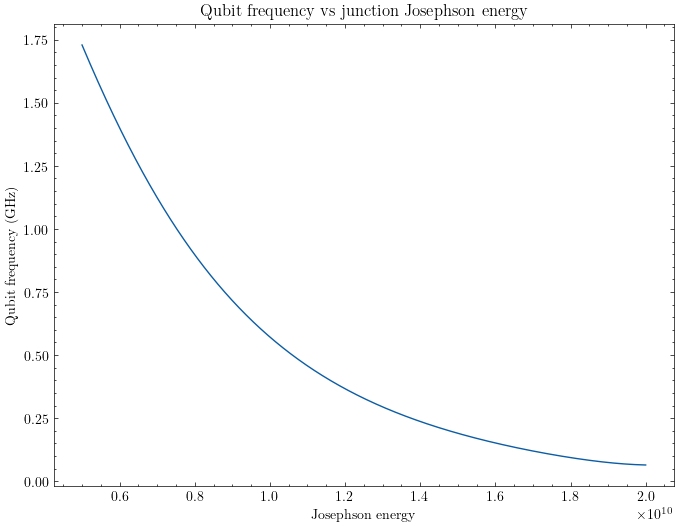

In [3]:
# josephson energy Ejp
system = BellCircuit(Ejp=6e9, Cjp=3e-15, Lp=400e-9, Cp=3e-15, Cg=3e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=5e-15, Cct=5e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)

Ejp_list = np.linspace(5e9, 20e9, 1501)
freq_list_varying_Ejp = []

for Ejp in Ejp_list:
    system.Ejp = Ejp * h
    evals, evecs = system.diagonalise_fluxonium(update = True)
    freq = system.get_fluxonium_frequency()
    freq_list_varying_Ejp.append(freq)

plt.figure(figsize=(8, 6))
plt.plot(Ejp_list, freq_list_varying_Ejp)

plt.title("Qubit frequency vs junction Josephson energy")
plt.xlabel("Josephson energy")
plt.ylabel("Qubit frequency (GHz)")
plt.show()

qubit frequency vs Josephson capacitance

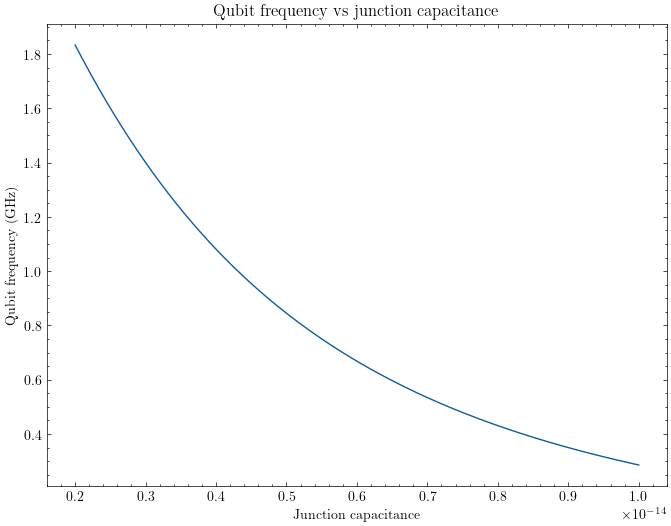

In [6]:
# josephson capacitance Cjp
system = BellCircuit(Ejp=6e9, Cjp=3e-15, Lp=400e-9, Cp=3e-15, Cg=3e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=5e-15, Cct=5e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)

Cjp_list = np.linspace(2e-15, 10e-15, 801)
freq_list_varying_Cjp = []

for Cjp in Cjp_list:
    system.Cjp = Cjp
    evals, evecs = system.diagonalise_fluxonium(update = True)
    freq = system.get_fluxonium_frequency()
    freq_list_varying_Cjp.append(freq)

plt.figure(figsize=(8, 6))
plt.plot(Cjp_list, freq_list_varying_Cjp)

plt.title("Qubit frequency vs junction capacitance")
plt.xlabel("Junction capacitance")
plt.ylabel("Qubit frequency (GHz)")
plt.show()

qubit frequency vs shunting capacitance

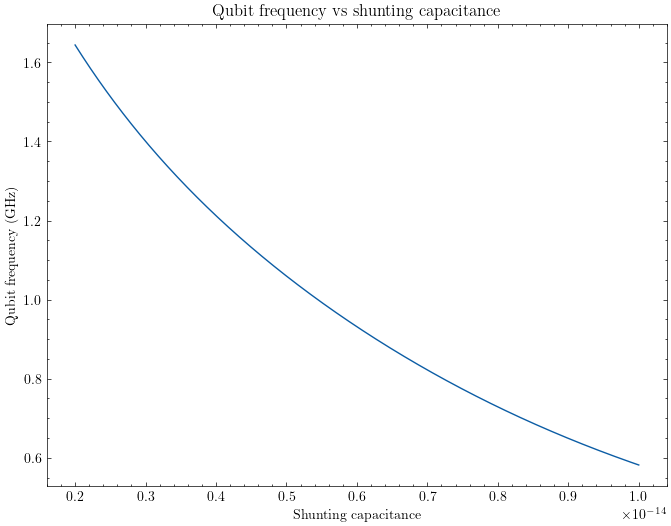

In [7]:
# shunting capacitance Cp
system = BellCircuit(Ejp=6e9, Cjp=3e-15, Lp=400e-9, Cp=3e-15, Cg=3e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=5e-15, Cct=5e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)

Cp_list = np.linspace(2e-15, 10e-15, 801)
freq_list_varying_Cp = []

for Cp in Cp_list:
    system.Cp = Cp
    evals, evecs = system.diagonalise_fluxonium(update = True)
    freq = system.get_fluxonium_frequency()
    freq_list_varying_Cp.append(freq)

plt.figure(figsize=(8, 6))
plt.plot(Cp_list, freq_list_varying_Cp)

plt.title("Qubit frequency vs shunting capacitance")
plt.xlabel("Shunting capacitance")
plt.ylabel("Qubit frequency (GHz)")
plt.show()

qubit frequency vs grounded capacitance

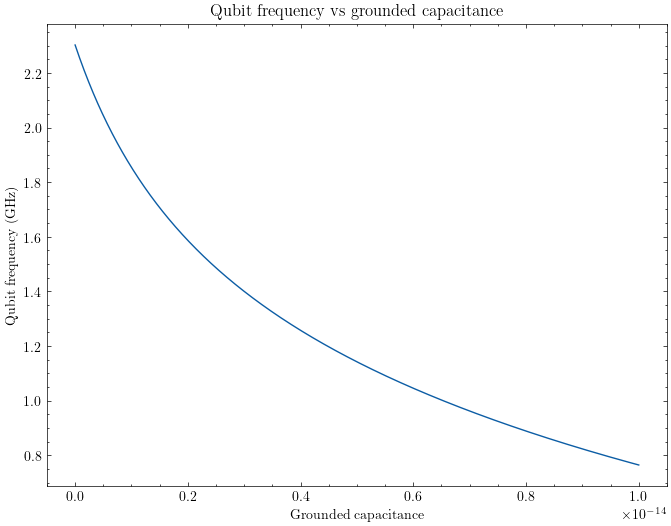

In [8]:
# grounded capacitance Cg
system = BellCircuit(Ejp=6e9, Cjp=3e-15, Lp=400e-9, Cp=3e-15, Cg=3e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=5e-15, Cct=5e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)

Cg_list = np.linspace(0e-15, 10e-15, 1001)
freq_list_varying_Cg = []

for Cg in Cg_list:
    system.Cg = Cg
    evals, evecs = system.diagonalise_fluxonium(update = True)
    freq = system.get_fluxonium_frequency()
    freq_list_varying_Cg.append(freq)

plt.figure(figsize=(8, 6))
plt.plot(Cg_list, freq_list_varying_Cg)

plt.title("Qubit frequency vs grounded capacitance")
plt.xlabel("Grounded capacitance")
plt.ylabel("Qubit frequency (GHz)")
plt.show()

qubit frequency vs probe-resonator coupling capacitance

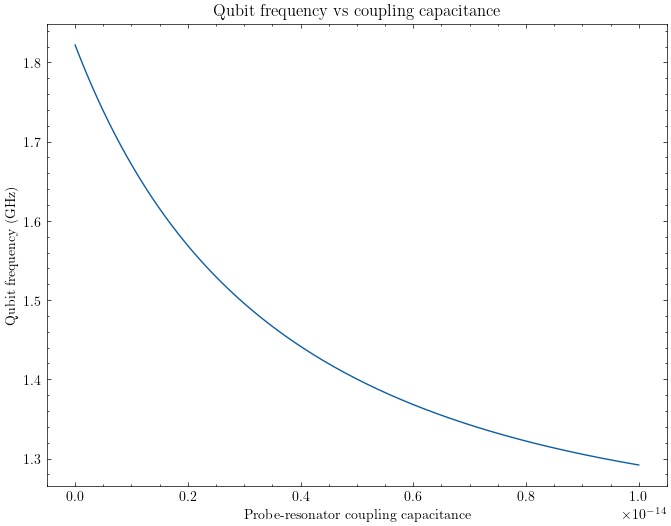

In [9]:
# probe-resonator coupling capacitance Ccp
system = BellCircuit(Ejp=6e9, Cjp=3e-15, Lp=400e-9, Cp=3e-15, Cg=3e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=5e-15, Cct=5e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)

Ccp_list = np.linspace(0e-15, 10e-15, 1001)
freq_list_varying_Ccp = []

for Ccp in Ccp_list:
    system.Ccp = Ccp
    evals, evecs = system.diagonalise_fluxonium(update = True)
    freq = system.get_fluxonium_frequency()
    freq_list_varying_Ccp.append(freq)

plt.figure(figsize=(8, 6))
plt.plot(Ccp_list, freq_list_varying_Ccp)

plt.title("Qubit frequency vs coupling capacitance")
plt.xlabel("Probe-resonator coupling capacitance")
plt.ylabel("Qubit frequency (GHz)")
plt.show()

coupling strength vs Josephson energy

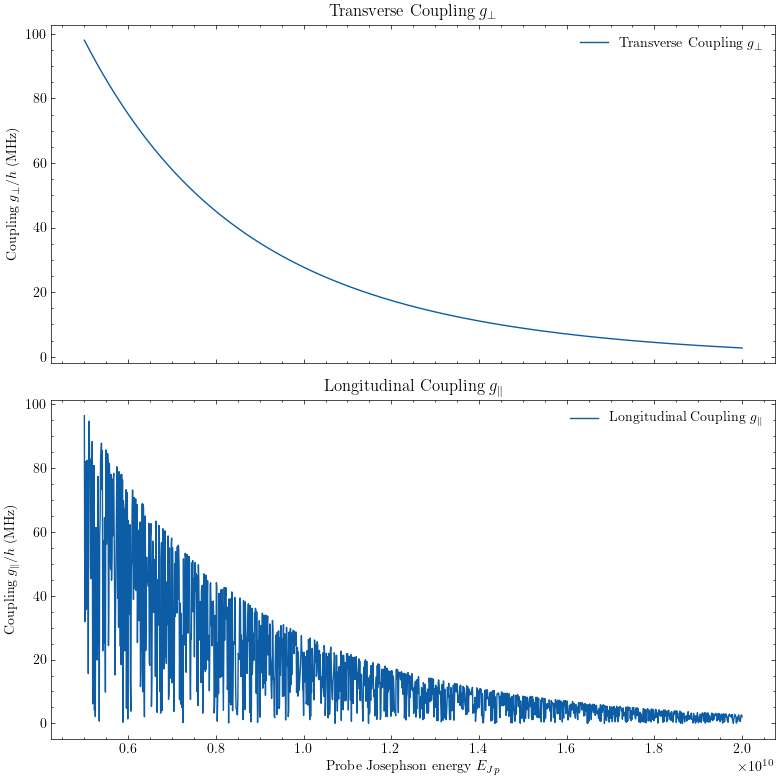

In [13]:
system = BellCircuit(Ejp=6e9, Cjp=3e-15, Lp=400e-9, Cp=3e-15, Cg=3e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=5e-15, Cct=5e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.5, ncut=5)

# transverse and longitudinal coupling between probe and resonator
g_transverse_varying_Ejp = []
g_longitudinal_varying_Ejp = []

for Ejp in Ejp_list:
    system.Ejp = Ejp * h
    
    g_perp = system.calc_g_perp(update = True)  # transverse coupling
    g_perp = np.abs(g_perp)  # transverse coupling strength
    
    g_parr = system.calc_g_parr(update = True)  # longitudinal coupling
    g_parr = np.abs(g_parr)  # longitudinal coupling strength

    g_transverse_varying_Ejp.append(g_perp)
    g_longitudinal_varying_Ejp.append(g_parr)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(Ejp_list, g_transverse_varying_Ejp, label="Transverse Coupling $g_\\perp$")
axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].plot(Ejp_list, g_longitudinal_varying_Ejp, label="Longitudinal Coupling $g_\\parallel$")
axs[1].set_xlabel("Probe Josephson energy $E_{Jp}$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

coupling strength vs Josephson capacitance

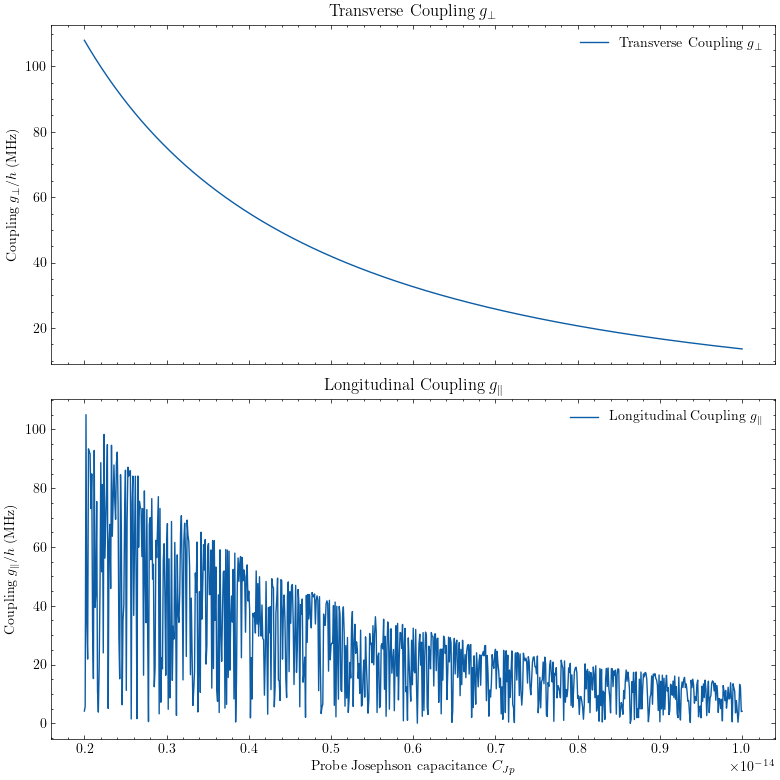

In [15]:
system = BellCircuit(Ejp=6e9, Cjp=3e-15, Lp=400e-9, Cp=3e-15, Cg=3e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=5e-15, Cct=5e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.5, ncut=5)

# transverse and longitudinal coupling between probe and resonator
g_transverse_varying_Cjp = []
g_longitudinal_varying_Cjp = []

for Cjp in Cjp_list:
    system.Cjp = Cjp
    
    g_perp = system.calc_g_perp(update = True)  # transverse coupling
    g_perp = np.abs(g_perp)  # transverse coupling strength
    
    g_parr = system.calc_g_parr(update = True)  # longitudinal coupling
    g_parr = np.abs(g_parr)  # longitudinal coupling strength

    g_transverse_varying_Cjp.append(g_perp)
    g_longitudinal_varying_Cjp.append(g_parr)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(Cjp_list, g_transverse_varying_Cjp, label="Transverse Coupling $g_\\perp$")
axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].plot(Cjp_list, g_longitudinal_varying_Cjp, label="Longitudinal Coupling $g_\\parallel$")
axs[1].set_xlabel("Probe Josephson capacitance $C_{Jp}$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

coupling strength vs shunting capacitance

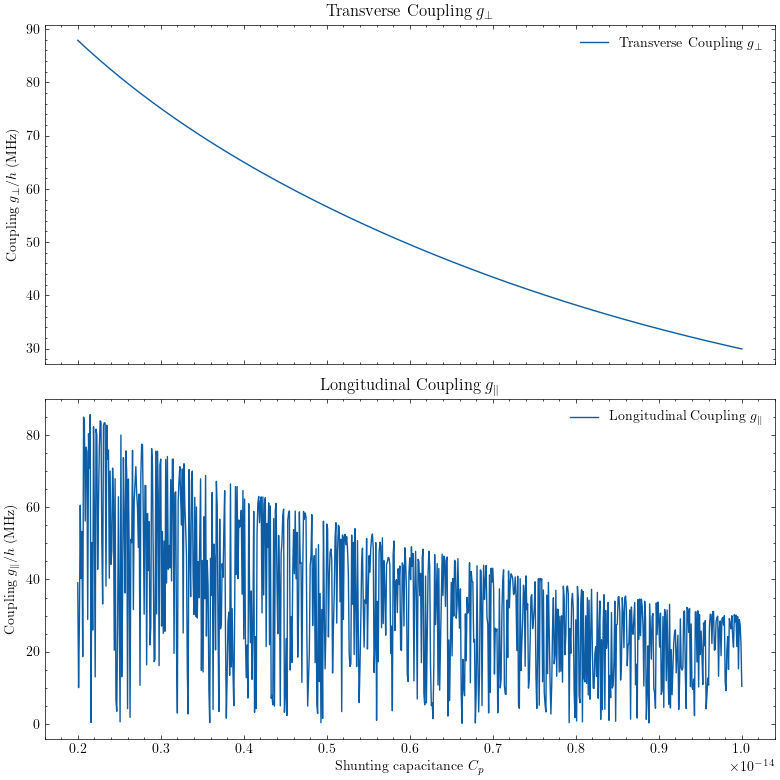

In [17]:
system = BellCircuit(Ejp=6e9, Cjp=3e-15, Lp=400e-9, Cp=3e-15, Cg=3e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=5e-15, Cct=5e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.5, ncut=5)

g_transverse_varying_Cp = []
g_longitudinal_varying_Cp = []

for Cp in Cp_list:
    system.Cp = Cp
    
    g_perp = system.calc_g_perp(update = True)  # transverse coupling
    g_perp = np.abs(g_perp)  # transverse coupling strength
    
    g_parr = system.calc_g_parr(update = True)  # longitudinal coupling
    g_parr = np.abs(g_parr)  # longitudinal coupling strength

    g_transverse_varying_Cp.append(g_perp)
    g_longitudinal_varying_Cp.append(g_parr)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(Cp_list, g_transverse_varying_Cp, label="Transverse Coupling $g_\\perp$")
axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].plot(Cp_list, g_longitudinal_varying_Cp, label="Longitudinal Coupling $g_\\parallel$")
axs[1].set_xlabel("Shunting capacitance $C_p$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

coupling strength vs grounded capacitance

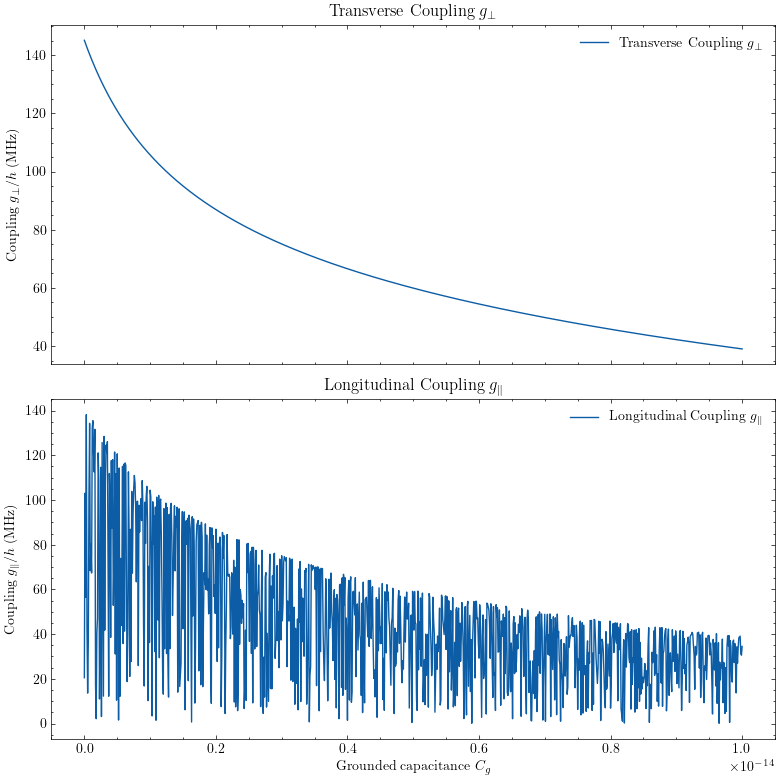

In [18]:
system = BellCircuit(Ejp=6e9, Cjp=3e-15, Lp=400e-9, Cp=3e-15, Cg=3e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=5e-15, Cct=5e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.5, ncut=5)

# transverse and longitudinal coupling between probe and resonator
g_transverse_varying_Cg = []
g_longitudinal_varying_Cg = []

for Cg in Cg_list:
    system.Cg = Cg
    
    g_perp = system.calc_g_perp(update = True)  # transverse coupling
    g_perp = np.abs(g_perp)  # transverse coupling strength
    
    g_parr = system.calc_g_parr(update = True)  # longitudinal coupling
    g_parr = np.abs(g_parr)  # longitudinal coupling strength

    g_transverse_varying_Cg.append(g_perp)
    g_longitudinal_varying_Cg.append(g_parr)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(Cg_list, g_transverse_varying_Cg, label="Transverse Coupling $g_\\perp$")
axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].plot(Cg_list, g_longitudinal_varying_Cg, label="Longitudinal Coupling $g_\\parallel$")
axs[1].set_xlabel("Grounded capacitance $C_g$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

coupling strength vs probe-resonator coupling capacitance

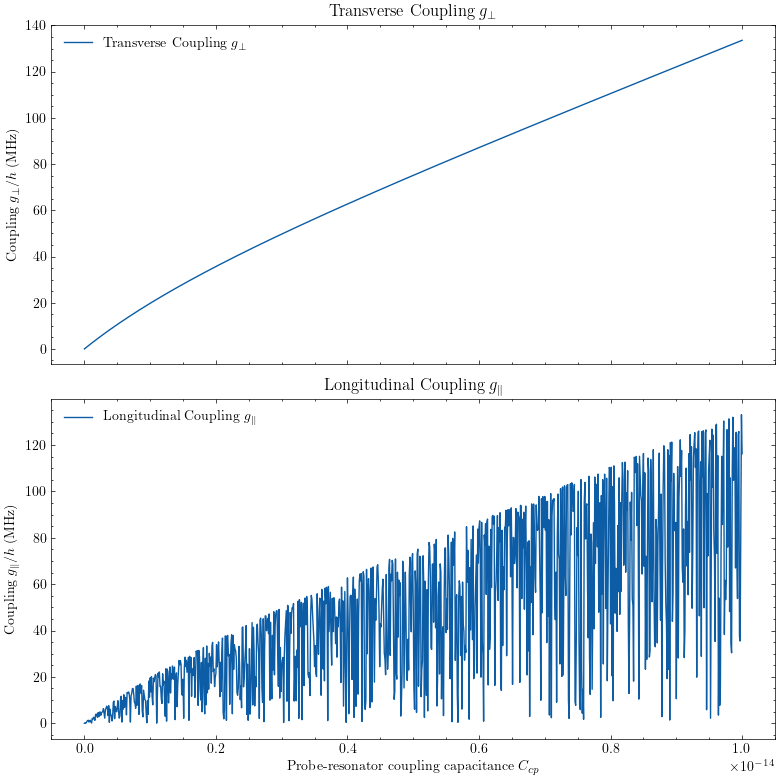

In [19]:
system = BellCircuit(Ejp=6e9, Cjp=3e-15, Lp=400e-9, Cp=3e-15, Cg=3e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=5e-15, Cct=5e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.5, ncut=5)

# transverse and longitudinal coupling between probe and resonator
g_transverse_varying_Ccp = []
g_longitudinal_varying_Ccp = []

for Ccp in Ccp_list:
    system.Ccp = Ccp
    
    g_perp = system.calc_g_perp(update = True)  # transverse coupling
    g_perp = np.abs(g_perp)  # transverse coupling strength
    
    g_parr = system.calc_g_parr(update = True)  # longitudinal coupling
    g_parr = np.abs(g_parr)  # longitudinal coupling strength

    g_transverse_varying_Ccp.append(g_perp)
    g_longitudinal_varying_Ccp.append(g_parr)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(Ccp_list, g_transverse_varying_Ccp, label="Transverse Coupling $g_\\perp$")
axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].plot(Ccp_list, g_longitudinal_varying_Ccp, label="Longitudinal Coupling $g_\\parallel$")
axs[1].set_xlabel("Probe-resonator coupling capacitance $C_{cp}$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

# (2) An example circuit system

In order to achieve large qubit gap and coupling strength, we aim for small $E_{jp}, C_{jp}, C_p, C_g$ and large $C_{cp}$.

In [28]:
system = BellCircuit(Ejp=6e9, Cjp=2e-15, Lp=400e-9, Cp=2e-15, Cg=0e-15,
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)

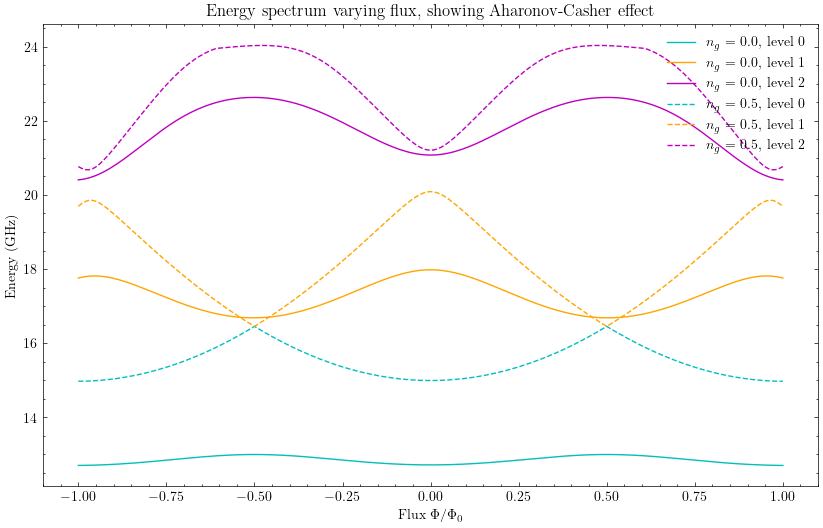

In [25]:
# qubit spectrum varying flux
# offset charge ng=0 and ng=0.5

flux_list = np.linspace(-1,1,201)
ng_list = [0.0, 0.5]


plt.figure(figsize=(10, 6))

for ng in ng_list:
    system.ng = ng
    evals_list = []
    
    for flux in flux_list:
        system.flux = flux
        evals, evecs = system.diagonalise_fluxonium(update=True)
        evals_list.append(evals[:3])

    evals_list = np.array(evals_list)
    evals_list = evals_list * 1e-9 / h
    
    label = f"$n_g$ = {ng}"
    for i, color in zip(range(3), ['c', 'orange', 'm']):
        plt.plot(flux_list, evals_list[:, i], color=color, linestyle='-' if ng==0 else '--', label=f'{label}, level {i}')

plt.title("Energy spectrum varying flux, showing Aharonov-Casher effect")
plt.xlabel("Flux $\\Phi / \\Phi_0$")
plt.ylabel("Energy (GHz)")
plt.legend()
plt.show()

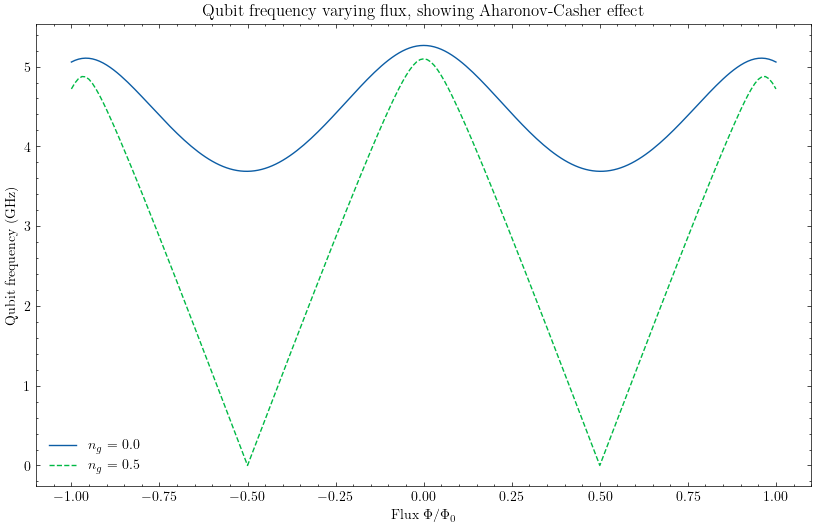

In [26]:
# qubit frequency varying flux
# offset charge ng=0 and ng=0.5

plt.figure(figsize=(10, 6))

for ng in ng_list:
    system.ng = ng
    freq_list = []

    for phi in flux_list:
        system.flux = phi
        evals, evecs = system.diagonalise_fluxonium(update = True)
        freq = system.get_fluxonium_frequency()
        freq_list.append(freq)
    
    label = f"$n_g$ = {ng}"
    plt.plot(flux_list, freq_list, linestyle='-' if ng==0 else '--', label=f'{label}')

plt.title("Qubit frequency varying flux, showing Aharonov-Casher effect")
plt.xlabel("Flux $\\Phi / \\Phi_0$")
plt.ylabel("Qubit frequency (GHz)")
plt.legend()
plt.show()

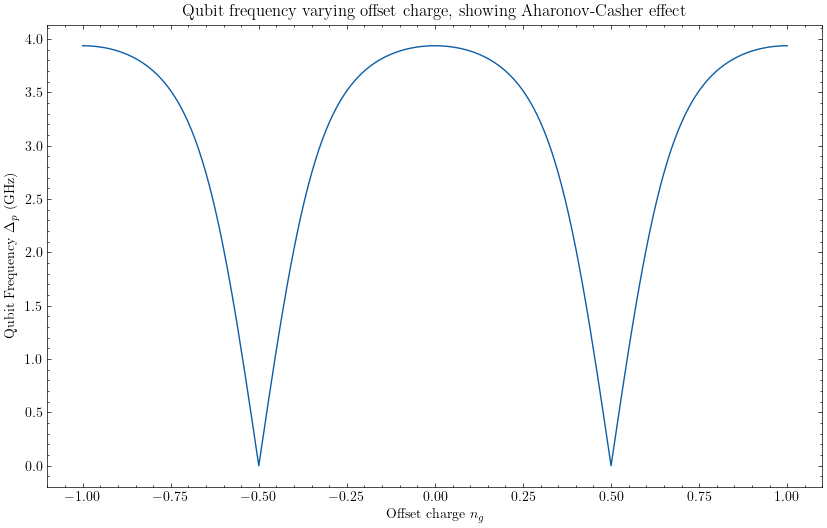

In [27]:
system = BellCircuit(Ejp=5e9, Cjp=2e-15, Lp=400e-9, Cp=2e-15, Cg=0e-15,
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)

# frequency varying offset charge
# flux kept at phi=0.5

ng_list_2 = np.linspace(-1, 1, 201)
freq_list_ng = []

for ng in ng_list_2:
    system.ng = ng
    evals, evecs = system.diagonalise_fluxonium(update = True)
    freq = system.get_fluxonium_frequency()
    freq_list_ng.append(freq)

plt.figure(figsize=(10, 6))
plt.plot(ng_list_2, freq_list_ng)
plt.xlabel("Offset charge $n_g$")
plt.ylabel("Qubit Frequency $\\Delta_p$ (GHz)")
plt.title("Qubit frequency varying offset charge, showing Aharonov-Casher effect")
plt.show()

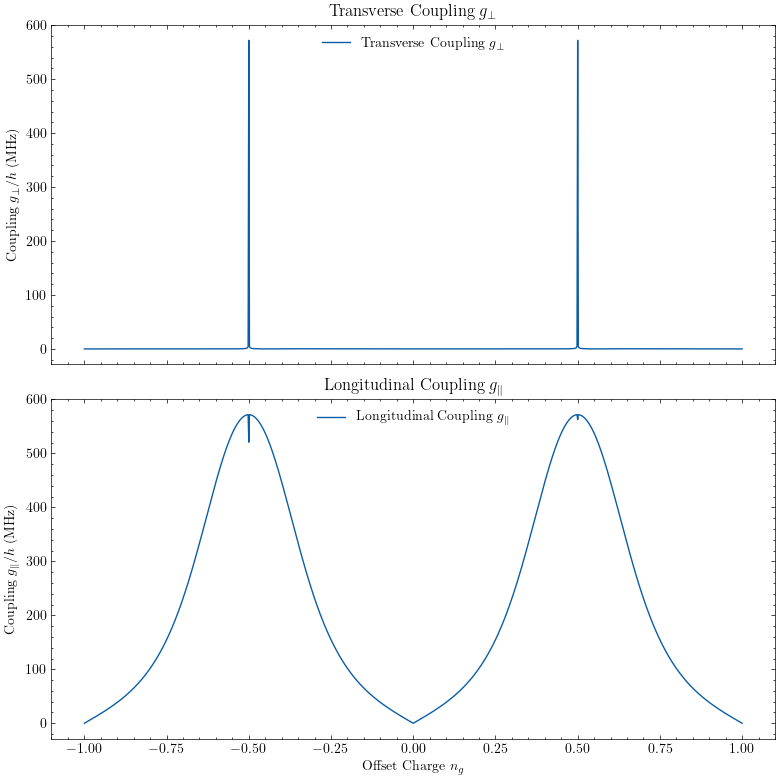

In [29]:
system = BellCircuit(Ejp=6e9, Cjp=2e-15, Lp=400e-9, Cp=2e-15, Cg=0e-15,
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)

ng_list_3 = np.linspace(-1, 1, 1001)

# transverse and longitudinal coupling between probe and resonator
g_transverse_ng = []
g_longitudinal_ng = []

# coupling dependence on offset charge, flux kept at phi=0.5
for ng in ng_list_3:
    system.ng = ng
    
    g_perp = system.calc_g_perp(update = True)  # transverse coupling
    g_perp = np.abs(g_perp)  # transverse coupling strength
    
    g_parr = system.calc_g_parr(update = True)  # longitudinal coupling
    g_parr = np.abs(g_parr)  # longitudinal coupling strength

    g_transverse_ng.append(g_perp)
    g_longitudinal_ng.append(g_parr)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(ng_list_3, g_transverse_ng, label="Transverse Coupling $g_\\perp$")
axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].plot(ng_list_3, g_longitudinal_ng, label="Longitudinal Coupling $g_\\parallel$")
axs[1].set_xlabel("Offset Charge $n_g$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

Overall, by tuning the optimal parameters, we can achieve a circuit system with 4GHz qubit gap at $\Phi=0.5, n_g=0$ and 600MHz longitudinal coupling strength at $\Phi=0.5, n_g=0.5$.

However the transverse coupling spikes and longitudinal coupling dips at the sweet spots cannot be eliminated only by tuning the parameters.

One advantage of the split fluxonium circuit is that we can achieve the desired results with relatively small $E_{Jp}, C_{Jp}$, while the four-junction flux qubit circuit requires large $E_{Jp}$ and satisfies $E_{Jp}\gg E_{Cp}$.

# (3) Flux detuning from $\Phi=0.5$: split fluxonium circuit

$\Phi=0.51$

In [31]:
system = BellCircuit(Ejp=6e9, Cjp=2e-15, Lp=400e-9, Cp=2e-15, Cg=0e-15,
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.51, ng=0.0, ncut=5)

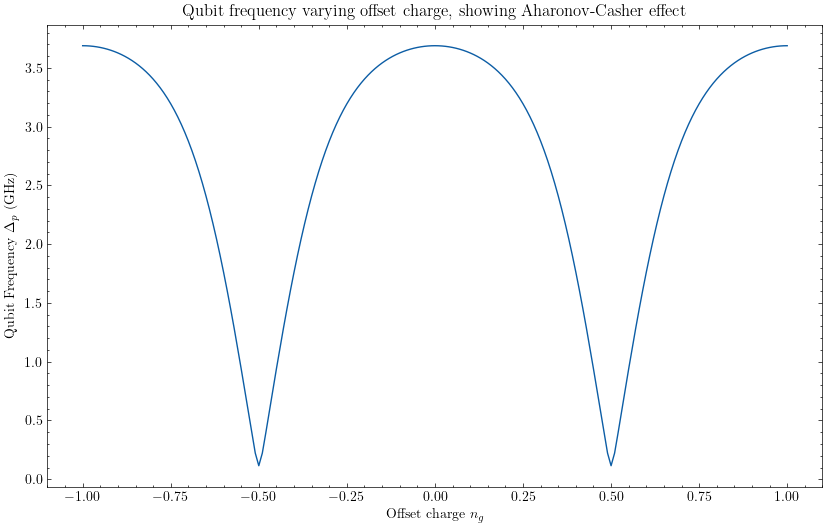

In [32]:
# frequency varying offset charge
# flux tuned slightly away at phi=0.51

ng_list_2 = np.linspace(-1, 1, 201)
freq_list_ng = []

for ng in ng_list_2:
    system.ng = ng
    evals, evecs = system.diagonalise_fluxonium(update = True)
    freq = system.get_fluxonium_frequency()
    freq_list_ng.append(freq)

plt.figure(figsize=(10, 6))
plt.plot(ng_list_2, freq_list_ng)
plt.xlabel("Offset charge $n_g$")
plt.ylabel("Qubit Frequency $\\Delta_p$ (GHz)")
plt.title("Qubit frequency varying offset charge, showing Aharonov-Casher effect")
plt.show()

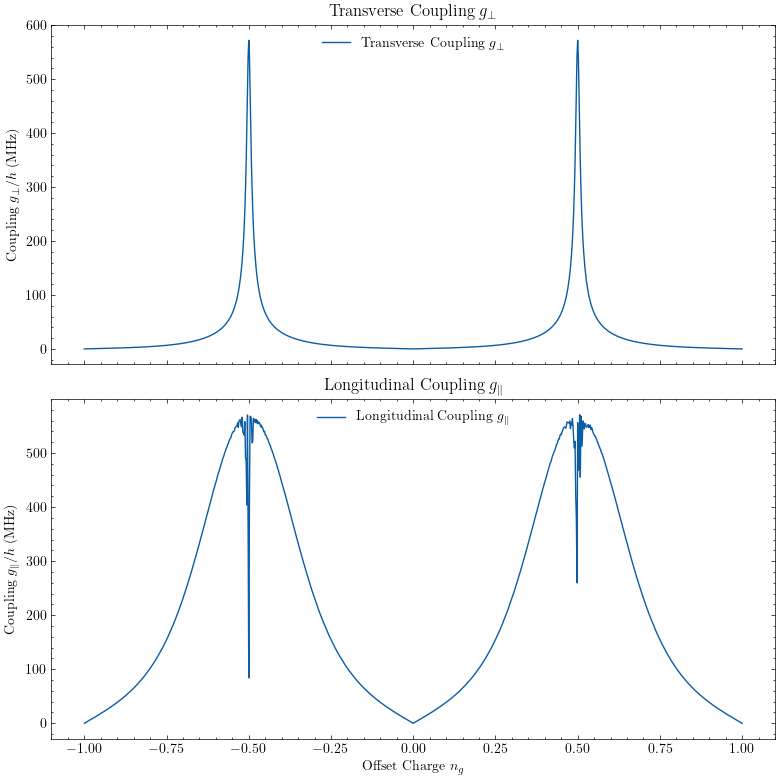

In [33]:
system = BellCircuit(Ejp=6e9, Cjp=2e-15, Lp=400e-9, Cp=2e-15, Cg=0e-15,
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.51, ng=0.0, ncut=5)

ng_list_3 = np.linspace(-1, 1, 1001)

# transverse and longitudinal coupling between probe and resonator
g_transverse_ng = []
g_longitudinal_ng = []

# coupling dependence on offset charge, flux kept at phi=0.5
for ng in ng_list_3:
    system.ng = ng
    
    g_perp = system.calc_g_perp(update = True)  # transverse coupling
    g_perp = np.abs(g_perp)  # transverse coupling strength
    
    g_parr = system.calc_g_parr(update = True)  # longitudinal coupling
    g_parr = np.abs(g_parr)  # longitudinal coupling strength

    g_transverse_ng.append(g_perp)
    g_longitudinal_ng.append(g_parr)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(ng_list_3, g_transverse_ng, label="Transverse Coupling $g_\\perp$")
axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].plot(ng_list_3, g_longitudinal_ng, label="Longitudinal Coupling $g_\\parallel$")
axs[1].set_xlabel("Offset Charge $n_g$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

$\Phi=0.501$

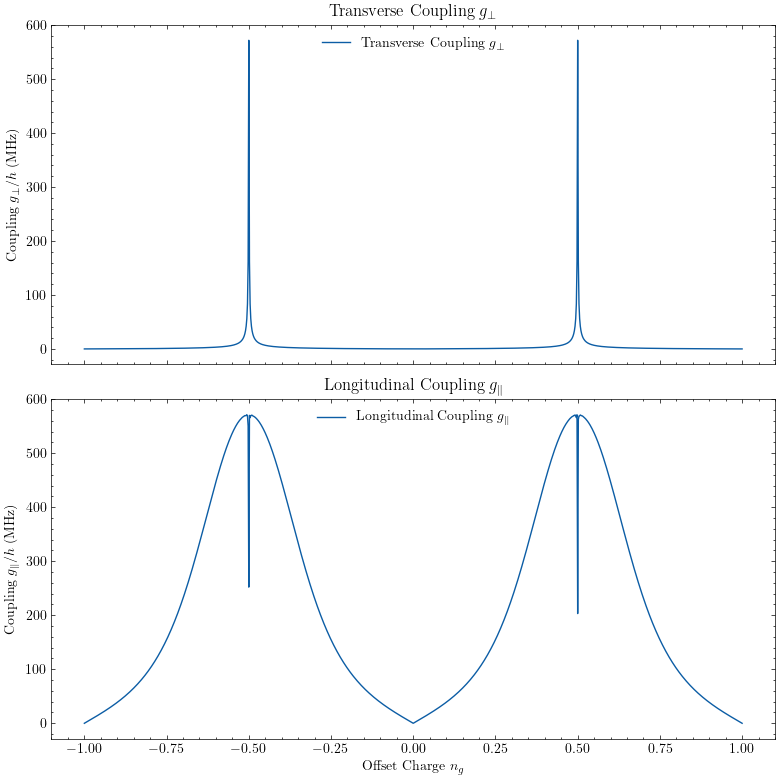

In [34]:
system = BellCircuit(Ejp=6e9, Cjp=2e-15, Lp=400e-9, Cp=2e-15, Cg=0e-15,
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.501, ng=0.0, ncut=5)

ng_list_3 = np.linspace(-1, 1, 1001)

# transverse and longitudinal coupling between probe and resonator
g_transverse_ng = []
g_longitudinal_ng = []

# coupling dependence on offset charge, flux kept at phi=0.5
for ng in ng_list_3:
    system.ng = ng
    
    g_perp = system.calc_g_perp(update = True)  # transverse coupling
    g_perp = np.abs(g_perp)  # transverse coupling strength
    
    g_parr = system.calc_g_parr(update = True)  # longitudinal coupling
    g_parr = np.abs(g_parr)  # longitudinal coupling strength

    g_transverse_ng.append(g_perp)
    g_longitudinal_ng.append(g_parr)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(ng_list_3, g_transverse_ng, label="Transverse Coupling $g_\\perp$")
axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].plot(ng_list_3, g_longitudinal_ng, label="Longitudinal Coupling $g_\\parallel$")
axs[1].set_xlabel("Offset Charge $n_g$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

Coupling strength sensitivity to flux detuning

100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [17:33<00:00, 263.47s/it]


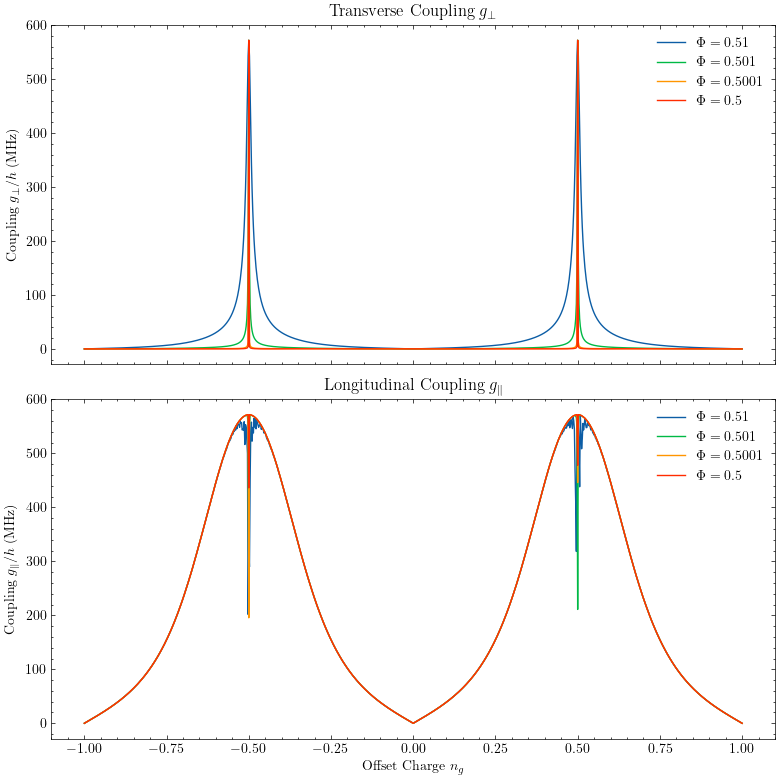

In [36]:
ng_vals = np.linspace(-1, 1, 1001)
flux_vals = [0.51, 0.501, 0.5001, 0.5]
results = {}

for flux in tqdm(flux_vals):
    system = BellCircuit(Ejp=6e9, Cjp=2e-15, Lp=400e-9, Cp=2e-15, Cg=0e-15,
                         Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                         Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=flux, ng=0.0, ncut=5)
    
    g_transverse_ng = []
    g_longitudinal_ng = []
    
    for ng in ng_vals:
        system.ng = ng
        
        g_perp = np.abs(system.calc_g_perp(update=True))   # transverse
        g_parr = np.abs(system.calc_g_parr(update=True))   # longitudinal
        
        g_transverse_ng.append(g_perp)
        g_longitudinal_ng.append(g_parr)
    
    results[flux] = (g_transverse_ng, g_longitudinal_ng)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for flux in flux_vals:
    g_transverse_ng, g_longitudinal_ng = results[flux]
    axs[0].plot(ng_vals, g_transverse_ng, label=f"$\Phi={flux}$")
    axs[1].plot(ng_vals, g_longitudinal_ng, label=f"$\Phi={flux}$")

axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].set_xlabel("Offset Charge $n_g$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

The split fluxonium circuit is sensible to both flux detuning and junction asymmetry, but only near the sweet spots at $n_g=\pm0.5$.

# (4) Flux detuning from $\Phi=0.5$: four-junction flux qubit circuit

In [38]:
from resonator_coupling_circuit_projected import RCCircuitCoup

The "RCCircuitCoup" module has been imported. This module allows to calculate the parallel and perpendicular coupling in a circuit of a flux qubit (probe) coupled to a resonator coupled to a transmon qubit. The method uses an Hamiltonian term projected into the probe qubit subspace.


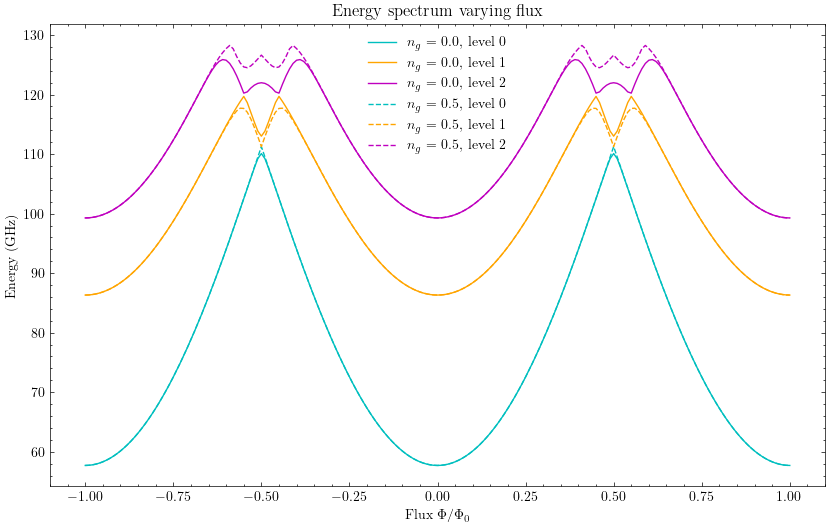

In [41]:
# large Ejp is required for the flux qubit circuit
system2 = RCCircuitCoup(Ejp=100e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.5,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0)

# energy spectrum varying flux
# offset charge ng=0 and ng=0.5
flux_list = np.linspace(-1,1,201)
ng_list = [0.0, 0.5]

plt.figure(figsize=(10, 6))

for ng in ng_list:
    system2.ng = ng
    evals_list = []
    
    for flux in flux_list:
        system2.flux = flux
        evals, evecs = system2.diagonalise_p(update=True)
        evals_list.append(evals[:3])

    evals_list = np.array(evals_list)
    evals_list = evals_list * 1e-9 / h
    
    label = f"$n_g$ = {ng}"
    for i, color in zip(range(3), ['c', 'orange', 'm']):
        plt.plot(flux_list, evals_list[:, i], color=color, linestyle='-' if ng==0 else '--', label=f'{label}, level {i}')

plt.title("Energy spectrum varying flux")
plt.xlabel("Flux $\\Phi / \\Phi_0$")
plt.ylabel("Energy (GHz)")
plt.legend()
plt.show()

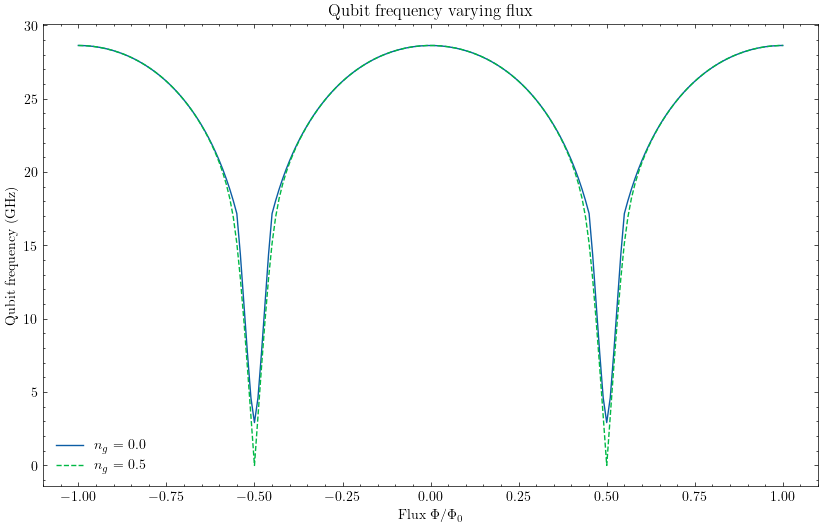

In [43]:
# qubit frequency varying flux
# offset charge ng=0 and ng=0.5
plt.figure(figsize=(10, 6))

for ng in ng_list:
    system2.ng = ng
    freq_list = []

    for phi in flux_list:
        system2.flux = phi
        evals, evecs = system2.diagonalise_p(update = True)
        evals = np.real(evals) * 1e-9 / h

        delta = evals[1] - evals[0]
        freq_list.append(delta)
    
    label = f"$n_g$ = {ng}"
    plt.plot(flux_list, freq_list, linestyle='-' if ng==0 else '--', label=f'{label}')

plt.title("Qubit frequency varying flux")
plt.xlabel("Flux $\\Phi / \\Phi_0$")
plt.ylabel("Qubit frequency (GHz)")
plt.legend()
plt.show()

Only near $\Phi=\pm0.5$, the energy and qubit frequency differ between $n_g=0$ and $n_g=0.5$.

Now we consider a similar case where $\Phi=0.51$:

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [00:21<00:00,  9.37it/s]


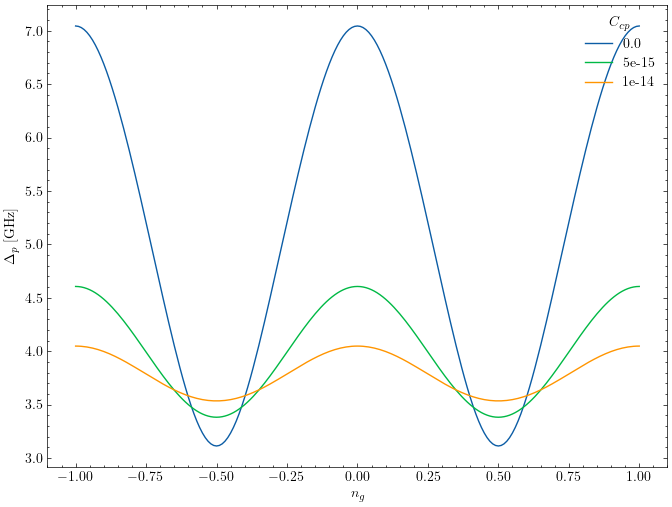

In [45]:
# flux detuning, phi=0.51

fig_17b_ngs_p = np.linspace(-1, 1, 201)
fig_17b_Ccps_p = [0e-15, 5e-15, 10e-15]

system2 = RCCircuitCoup(Ejp=100e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.51,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0)

fig_17b_results_p = {}

for CcpV in fig_17b_Ccps_p:
    fig_17b_results_p[CcpV] = []
    system2.Ccp = CcpV

    for ng in tqdm(fig_17b_ngs_p):
        system2.ng = ng

        delta = system2.calc_probe_freq(update=True) * 1e-9 / h

        fig_17b_results_p[CcpV].append(delta)

plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes

#plt.title('Qubit energy gap (calculated from eigenenergies)')
plt.xlabel('$n_g$')
plt.ylabel('$\\Delta_p$ [GHz]')

plt.rc('font')

for Ccp in fig_17b_results_p.keys():
    plt.plot(fig_17b_ngs_p, fig_17b_results_p[Ccp], label=Ccp)

legend =plt.legend(title='$C_{cp}$', loc= 'upper right')

plt.show()

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [00:18<00:00, 10.69it/s]


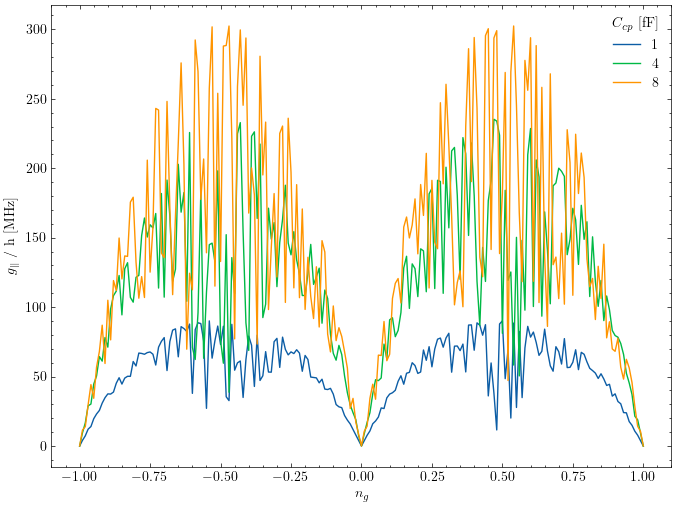

In [46]:
# flux detuning, phi=0.51

fig_17c_ngs_p = np.linspace(-1, 1, 201)
fig_17c_Ccps_p = [1e-15, 4e-15, 8e-15]

system2 = RCCircuitCoup(Ejp=100e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.51,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0)

fig_17c_g_parr_results = {}
fig_17c_g_perp_results = {}

for CcpV in fig_17c_Ccps_p:
    fig_17c_g_parr_results[CcpV] = []
    fig_17c_g_perp_results[CcpV] = []
    system2.Ccp = CcpV

    for ng in tqdm(fig_17c_ngs_p):
        system2.ng = ng

        system2.init_probe_states(update=True)

        g_parr = system2.calc_g_parr() * 1e-6 / h
        g_perp = system2.calc_g_perp() * 1e-6 / h

        fig_17c_g_parr_results[CcpV].append(g_parr)
        fig_17c_g_perp_results[CcpV].append(g_perp)

plt.figure(figsize=(8,6))

ax = plt.gca()  # Get the current axes

plt.xlabel('$n_g$')
plt.ylabel('$g_\\parallel$ / h [MHz]',)

plt.rc('font')

for Ccp in fig_17c_g_parr_results.keys():
    plt.plot(fig_17c_ngs_p, np.abs(fig_17c_g_parr_results[Ccp]), label=round(Ccp * 1e15))

legend = plt.legend(title='$C_{cp}$ [fF]', loc= 'upper right')

plt.show()

As we can see, flux detuning significantly impacts the qubit frequency and coupling strength values, not only near the sweet spots at $n_g=\pm0.5$.

We examine the coupling strength sensitivity to flux detuning:

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [01:05<00:00,  3.07it/s]


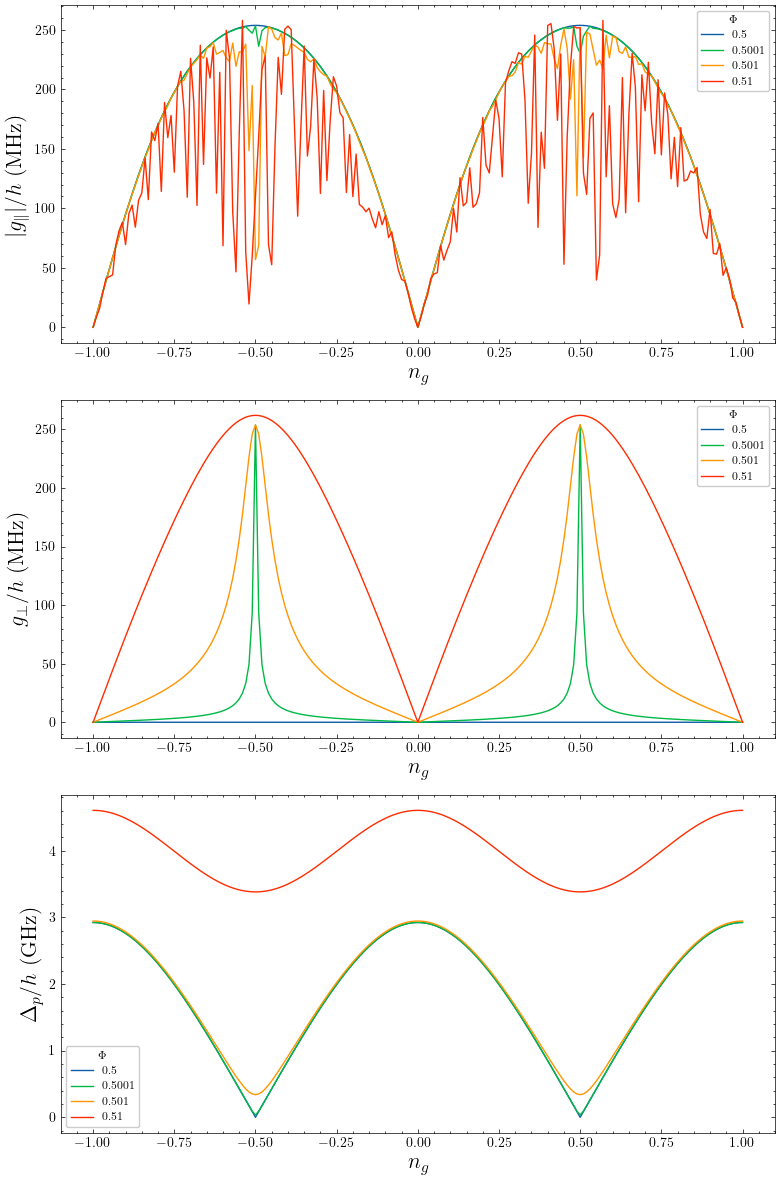

In [48]:
fig_17c_ngs_p = np.linspace(-1, 1, 201)
flux2s = [0.5,0.5001,0.501,0.51]

system2 = RCCircuitCoup(Ejp=100e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.5,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0)

flux_disp_results = {}

for flux2 in flux2s:
    if flux2 in flux_disp_results.keys():
        continue

    flux_disp_results[flux2] = {
        'ng': [],
        'g_parr': [],
        'g_perp': [],
        'probe_freq': [],
    }

    system2.flux = flux2
    for ng in tqdm(fig_17c_ngs_p):
        system2.ng = ng

        g_parr = system2.calc_g_parr(update=True) * 1e-6 / h
        g_perp = system2.calc_g_perp(update=True) * 1e-6 / h
        probe_freq = system2.calc_probe_freq(update=True) * 1e-9 / h

        flux_disp_results[flux2]['ng'].append(ng)
        flux_disp_results[flux2]['g_parr'].append(g_parr)
        flux_disp_results[flux2]['g_perp'].append(g_perp)
        flux_disp_results[flux2]['probe_freq'].append(probe_freq)

obserables = [
    {'name': 'g_parr', 'ylabel': '$|g_\\parallel| / h$ (MHz)'},
    {'name': 'g_perp', 'ylabel': '$g_\\perp / h$ (MHz)'},
    {'name': 'probe_freq', 'ylabel': '$\\Delta_p / h$ (GHz)'},
]

fig, ax = plt.subplots(figsize=(8, 12), nrows=3, ncols=1)
ax = ax.flatten()
for idx, obs in enumerate(obserables):
    pparam = dict(xlabel='$n_g$', ylabel=obs['ylabel'])

    with plt.style.context(['ieee', 'grid']):
        for flux in flux_disp_results.keys():
            ax[idx].plot(flux_disp_results[flux]['ng'], np.abs(flux_disp_results[flux][obs['name']]), label=flux)
        
        if 'y_lim' in obs.keys():
            ax[idx].set_ylim(obs['y_lim'])
        
        ax[idx].legend(title='$\\Phi$')
        ax[idx].set(**pparam)
        ax[idx].xaxis.label.set_size(16)
        ax[idx].yaxis.label.set_size(16)

plt.tight_layout()
plt.show()

We also show the coupling strength sensitivity to junction asymmetry here, from Elena's work:

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [01:05<00:00,  3.08it/s]


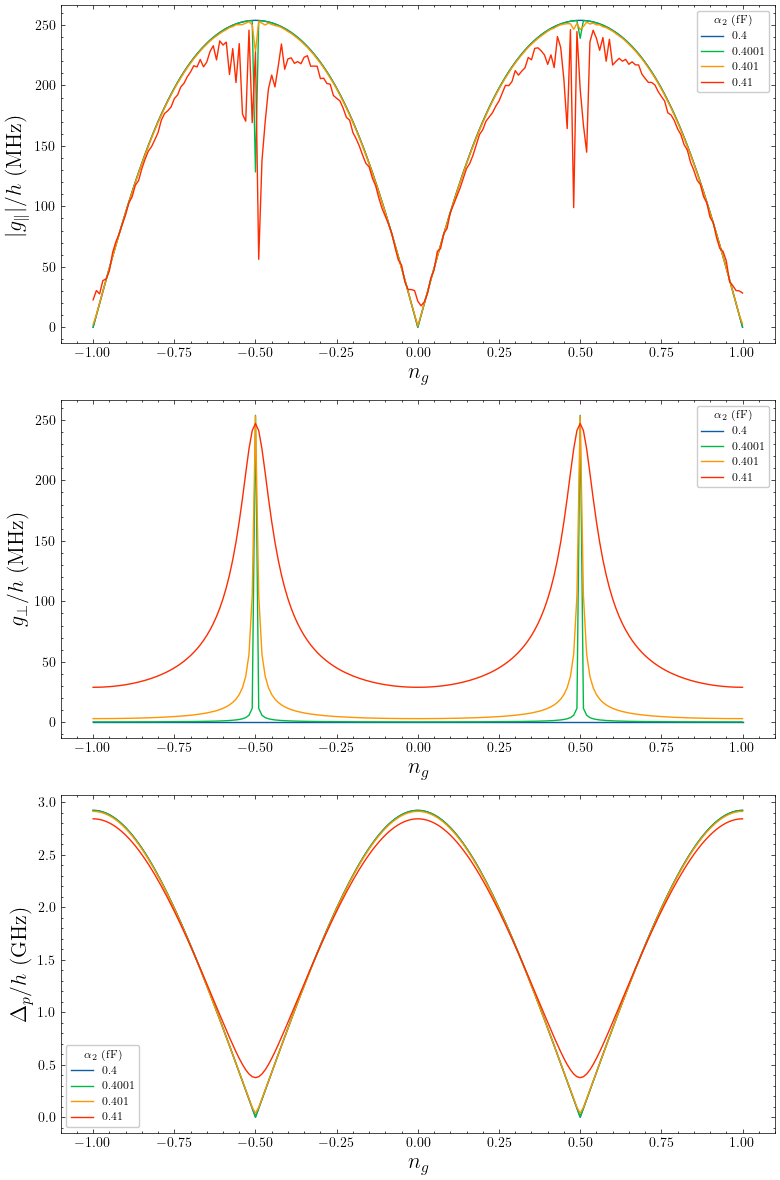

In [49]:
fig_17c_ngs_p = np.linspace(-1, 1, 201)
alpha2s = [0.4,0.4001,0.401,0.41]

system2 = RCCircuitCoup(Ejp=100e9, Ejt=5e9, Cjp=8e-15, Ccp=5e-15, alphas=[0.4, 0.4, 1, 1], flux=0.5,
                 Cr=100e-15, Lr=10e-9,  Cjt=4e-15, Cct=5e-15, Ct=40e-15, ncut=5, ng=0)

alpha_disp_results = {}

for alpha2 in alpha2s:
    if alpha2 in alpha_disp_results.keys():
        continue

    alpha_disp_results[alpha2] = {
        'ng': [],
        'g_parr': [],
        'g_perp': [],
        'probe_freq': [],
        #'cavity_freq': [],
        #'target_freq': []
    }

    system2.alphas = [0.4, alpha2, 1, 1] 
    for ng in tqdm(fig_17c_ngs_p):
        system2.ng = ng

        g_parr = system2.calc_g_parr(update=True) * 1e-6 / h
        g_perp = system2.calc_g_perp(update=True) * 1e-6 / h
        probe_freq = system2.calc_probe_freq(update=True) * 1e-9 / h

        alpha_disp_results[alpha2]['ng'].append(ng)
        alpha_disp_results[alpha2]['g_parr'].append(g_parr)
        alpha_disp_results[alpha2]['g_perp'].append(g_perp)
        alpha_disp_results[alpha2]['probe_freq'].append(probe_freq)

obserables = [
    {'name': 'g_parr', 'ylabel': '$|g_\\parallel| / h$ (MHz)'},
    {'name': 'g_perp', 'ylabel': '$g_\\perp / h$ (MHz)'},
    {'name': 'probe_freq', 'ylabel': '$\\Delta_p / h$ (GHz)'},
]

fig, ax = plt.subplots(figsize=(8, 12), nrows=3, ncols=1)
ax = ax.flatten()
for idx, obs in enumerate(obserables):
    pparam = dict(xlabel='$n_g$', ylabel=obs['ylabel'])

    with plt.style.context(['ieee', 'grid']):
        for alpha in alpha_disp_results.keys():
            ax[idx].plot(alpha_disp_results[alpha]['ng'], np.abs(alpha_disp_results[alpha][obs['name']]), label=alpha)
        
        if 'y_lim' in obs.keys():
            ax[idx].set_ylim(obs['y_lim'])
        
        ax[idx].legend(title='$\\alpha_2$ (fF)')
        ax[idx].set(**pparam)
        ax[idx].xaxis.label.set_size(16)
        ax[idx].yaxis.label.set_size(16)

plt.tight_layout()
plt.show()


The four-junction circuit is more sensible to left and right junction asymmetry, as well as flux detuning away from $\Phi=0.5$, not only near the sweet spots.

In order to observe zero qubit gap (energy level crossing) and maximum longitudinal coupling strength, we have to operate at exactly $\Phi=0.5$, $n_g=0.5$, and identical asymmetries between left and right junctions.

# (5) Coherence time

Split fluxonium circuit reduces flux sensitivity with large inductive shunt, just like a conventional fluxonium circuit. At $\Phi=0.5$ fluxoniums are even practically unaffected by the background 1/f flux noise. Reduced 1/f flux noise may lead to longer coherence time.

Experiments have shown $T_1$ and $T_2$ routinely over 100$\mu$s for typical fluxonium devices. (Nguyen, Long B., et al. "High-coherence fluxonium qubit." Physical Review X 9.4 (2019): 041041.)

And even up to 1ms in certain fluxonium-based devices. (Somoroff, Aaron, et al. "Millisecond coherence in a superconducting qubit." Physical Review Letters 130.26 (2023): 267001.)